In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Folder where all the CSVs are stored
data_dir = Path("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/Monahan2019_ORC/losses")

# Find all model CSVs
csv_files = sorted(data_dir.glob("Akita_v2_mouse_Monahan2019_ORC_model*_LR0.005_finetuned.csv"))

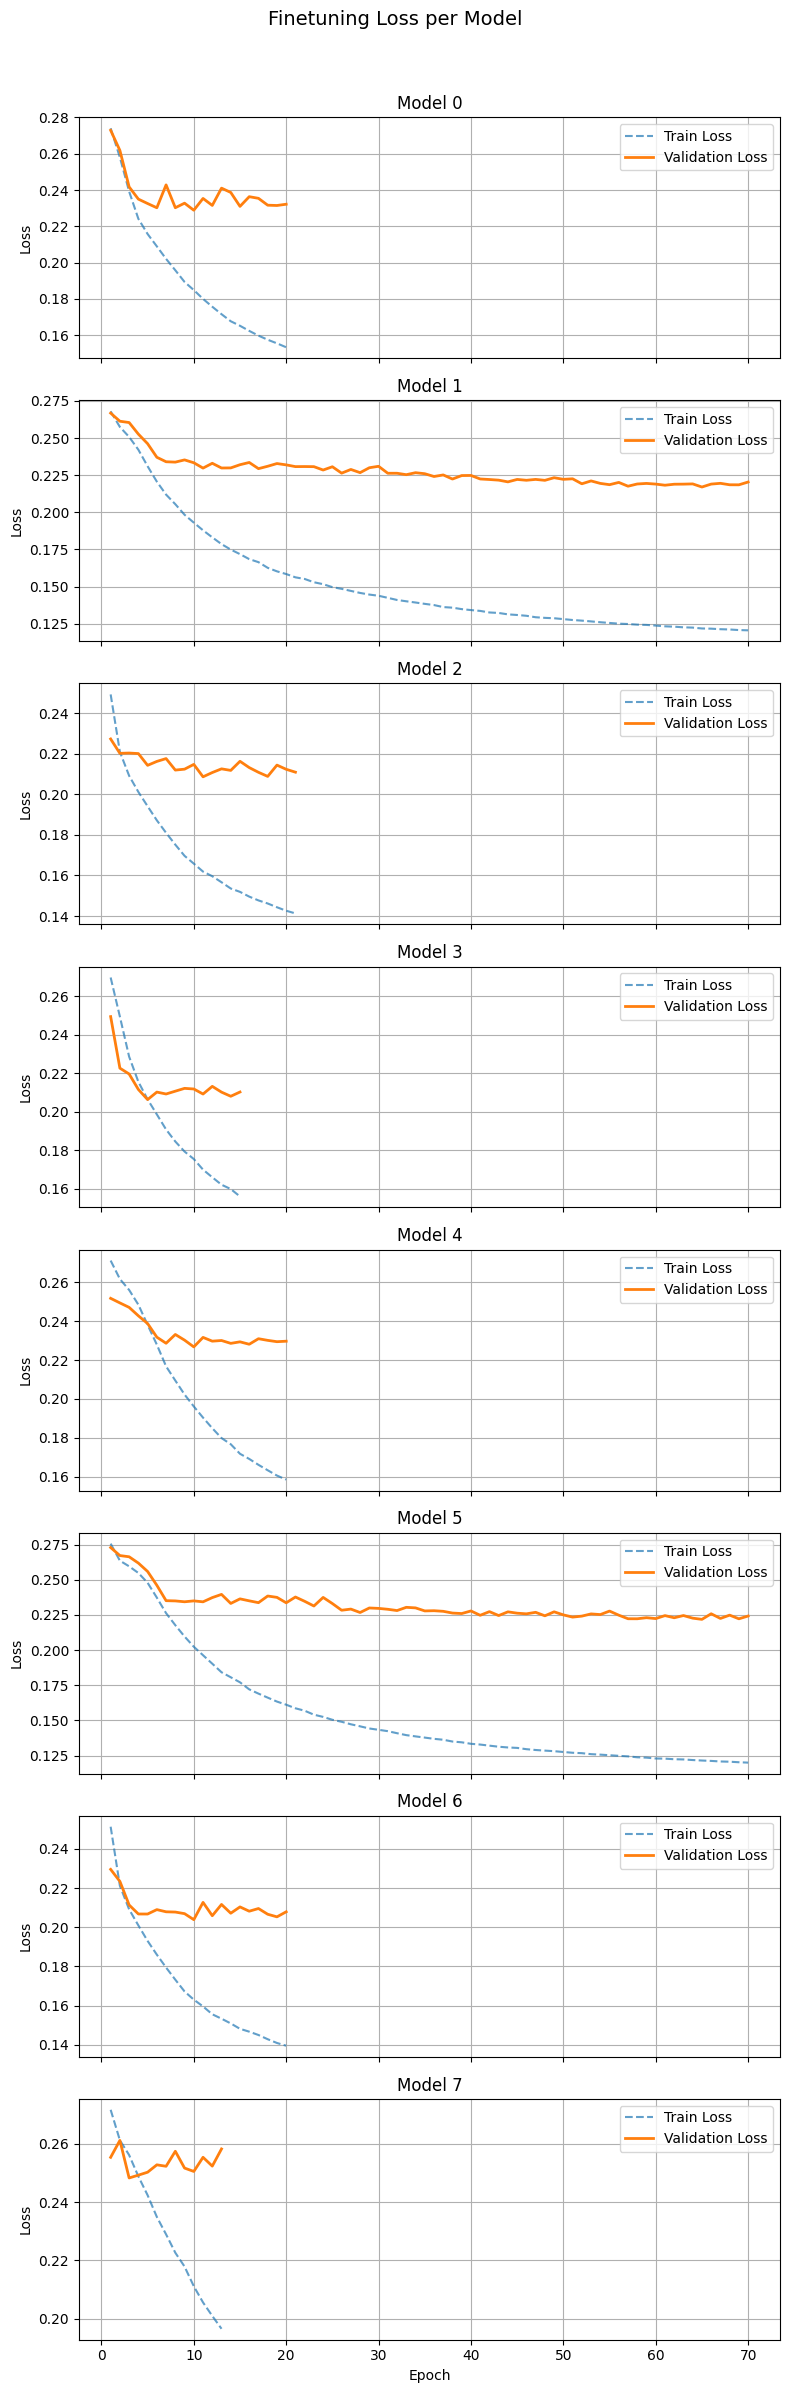

In [3]:
# One subplot per model
n_models = len(csv_files)
fig, axes = plt.subplots(n_models, 1, figsize=(8, 3 * n_models), sharex=True)

if n_models == 1:
    axes = [axes]  # Make it iterable if there's only one file

for ax, csv_file in zip(axes, csv_files):
    model_id = csv_file.stem.split("_model")[-1].split("_")[0]
    df = pd.read_csv(csv_file)

    ax.plot(df["Epoch"], df["Train Loss"], label="Train Loss", linestyle='--', alpha=0.7)
    ax.plot(df["Epoch"], df["Validation Loss"], label="Validation Loss", linewidth=2)
    ax.set_title(f"Model {model_id}")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Epoch")

plt.suptitle("Finetuning Loss per Model", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()